# 🧠 BCI-VR 전처리 파이프라인 — 멤버 A
## Google Colab (T4 GPU) 버전

---

| 항목 | 값 |
|---|---|
| **런타임** | GPU → T4, RAM 표준(12~16GB) |
| **데이터셋** | GigaDB (Cho 2017) — EEG 64ch + sEMG 4ch · 52명 |
| **BPF** | 4 – 40 Hz (4차 버터워스) |
| **ICA** | 25 성분, EOG + 근육 아티팩트 제거 |
| **Epoch** | -0.5 ~ 4.0 s · PTP 600μV 기준 자동 완화 |
| **EMG 포락선** | RMS (50 ms 윈도우) |
| **정규화** | z-score (채널별) |

> ### ✅ 실행 전 체크리스트
> 1. **런타임 → 런타임 유형 변경 → GPU: T4** 선택
> 2. Google Drive에 `BCI_Research/GigaDB_100295/` 폴더와 `.mat` 파일 업로드 확인
> 3. **셀을 위에서 아래로 순서대로** 실행
>
> ⚠️ T4 + 16GB RAM 환경에서는 `n_jobs=1` (순차 처리)로 설정됩니다.
> 52명 전체 처리 약 **2~3시간** 소요. 중단되어도 이어서 실행 가능합니다.


---
## STEP 0 — 환경 확인 & Drive 마운트

In [31]:
import subprocess, os, psutil, torch

print('='*60)
print('  Colab 실행 환경 확인')
print('='*60)

# GPU 확인
gpu = subprocess.run(
    ['nvidia-smi','--query-gpu=name,memory.total,memory.free',
     '--format=csv,noheader'],
    capture_output=True, text=True
)
if gpu.returncode == 0:
    gpu_info = gpu.stdout.strip()
    print(f'🖥️  GPU  : {gpu_info}')
    if 'T4' in gpu_info:
        print('   ✅ T4 감지')
    elif 'A100' in gpu_info or 'L4' in gpu_info:
        print('   ✅ Pro+ GPU 감지 — n_jobs=4로 변경 권장')
else:
    print('   ❌ GPU 없음 — 런타임에서 T4 선택 필요')

# RAM 확인
ram = psutil.virtual_memory()
print(f'💾 RAM  : {ram.total/1e9:.1f} GB (여유 {ram.available/1e9:.1f} GB)')
if ram.total/1e9 >= 40:
    print('   ✅ High-RAM — n_jobs=4 사용 가능')
else:
    print(f'   ℹ️  표준 RAM — n_jobs=1 (순차 처리) 권장')

# 디스크
disk = psutil.disk_usage('/')
print(f'💿 디스크: {disk.total/1e9:.0f} GB (여유 {disk.free/1e9:.0f} GB)')

# PyTorch
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    DEVICE = 'cuda'
    print(f'⚡ TF32 + cuDNN benchmark 활성화')
else:
    DEVICE = 'cpu'
    print('⚠️  CUDA 없음 — CPU 모드')

print('='*60)


  Colab 실행 환경 확인
🖥️  GPU  : Tesla T4, 15360 MiB, 14910 MiB
   ✅ T4 감지
💾 RAM  : 13.6 GB (여유 9.0 GB)
   ℹ️  표준 RAM — n_jobs=1 (순차 처리) 권장
💿 디스크: 253 GB (여유 195 GB)
⚡ TF32 + cuDNN benchmark 활성화


In [32]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_ROOT  = '/content/drive/MyDrive/BCI_Research'
LOCAL_CACHE = '/content/data_cache'
for d in [f'{DRIVE_ROOT}/GigaDB_100295', f'{DRIVE_ROOT}/preprocessed/member_A',
          f'{DRIVE_ROOT}/configs', f'{DRIVE_ROOT}/results', LOCAL_CACHE]:
    os.makedirs(d, exist_ok=True)
print('✅ Drive 마운트 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive 마운트 완료


In [33]:
%pip install mne==1.7.0 h5py scipy numpy matplotlib pandas tqdm joblib -q
import torch, numpy as np
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    DEVICE = 'cuda'
    print(f'✅ {torch.cuda.get_device_name(0)} | TF32 ON')
else:
    DEVICE = 'cpu'

✅ Tesla T4 | TF32 ON


---
## STEP 1 — Config (v4 수정 파라미터 포함)

In [34]:
import json
from datetime import datetime

CONFIG = {
    'member': 'A', 'strategy': 'baseline_v4', 'random_seed': 42,

    # EEG
    'eeg_fs': 512, 'bpf_low': 4.0, 'bpf_high': 40.0, 'bpf_order': 4,
    'epoch_tmin': -0.5, 'epoch_tmax': 4.0, 'baseline': (-0.5, 0.0),
    'reject_thresh_ptp': 600.0,        # ▶ PTP 기준: 정상EEG 100~400μV, 아티팩트 600↑
    'eeg_unit': 'uV',
    'mu_band': (8, 12), 'beta_band': (13, 30),
    'norm_method': 'zscore',
    'eeg_field': ['imagery_left', 'imagery_right'],
    'event_field': 'imagery_event', 'event_threshold': 0,

    # ▶ v4: ICA
    'n_ica': 25,
    'ica_hp_for_fit': 1.0,             # ICA 전용 highpass (Hz)
    'eog_threshold_z': 3.0,            # MNE 표준 z-score
    'use_muscle_ica': True,            # ▶ 활성화
    'muscle_threshold': 0.8,           # 보수적
    'protect_motor_ica': True,         # C3/C4/Cz 강하게 투영된 IC는 muscle 라벨이어도 보존
    'motor_protect_chs': ['C3','C1','Cz','C2','C4','FC3','FC1','FCz','FC2','FC4',
                          'CP3','CP1','CPz','CP2','CP4'],

    # ▶ v4: sEMG 전용 파이프라인
    'use_emg': True,
    'extract_emg_from_eeg': True,
    'emg_fs': 512,
    'emg_bpf_low': 20.0,
    'emg_bpf_high': 124.0,             # Nyquist(256) 대비 안전 여유
    'emg_notch_hz': [60.0, 120.0],     # 미국 60Hz; 한국 데이터면 [50,100]으로 변경
    'emg_window_ms': 50,
    'emg_envelope': 'rms',             # 'rms' | 'mav' | 'hilbert'
    'emg_snr_min': 3.0,                # MI 구간 / 베이스라인 RMS 비
    'emg_validate_split': False,        # 마지막 4채널이 EMG인지 통계 검증

    # 병렬
    # ── T4 환경 설정 ───────────────────────────────────────────
    # T4(16GB RAM): n_jobs=1 필수 (병렬 시 메모리 부족)
    # Pro+(52GB RAM): n_jobs=4 로 변경 가능
    'n_jobs'    : 1,          # T4: 1 고정 / Pro+: 4
    'use_cache' : True,       # Drive → 로컬 SSD 캐시 (속도 향상)
    'force_redo': True,       # 첫 실행 True, 이후 False

    'data_dir': f'{DRIVE_ROOT}/GigaDB_100295',
    'cache_dir': LOCAL_CACHE,
    'output_dir': f'{DRIVE_ROOT}/preprocessed/member_A',
    'results_csv': f'{DRIVE_ROOT}/results/results.csv',
    'n_subjects': 52,
    'classes': {1: 'Left_MI', 2: 'Right_MI'},
}

with open(f"{DRIVE_ROOT}/configs/config_member_A_v4.json", 'w') as f:
    json.dump(CONFIG, f, indent=2, default=str)
print('✅ Config v4 저장')
for k in ['bpf_low','bpf_high','n_ica','ica_hp_for_fit','eog_threshold_z',
          'use_muscle_ica','muscle_threshold','emg_bpf_low','emg_bpf_high',
          'emg_notch_hz','emg_envelope','reject_thresh_ptp','force_redo']:
    print(f'  {k:22s}: {CONFIG[k]}')

✅ Config v4 저장
  bpf_low               : 4.0
  bpf_high              : 40.0
  n_ica                 : 25
  ica_hp_for_fit        : 1.0
  eog_threshold_z       : 3.0
  use_muscle_ica        : True
  muscle_threshold      : 0.8
  emg_bpf_low           : 20.0
  emg_bpf_high          : 124.0
  emg_notch_hz          : [60.0, 120.0]
  emg_envelope          : rms
  reject_thresh_ptp     : 600.0
  force_redo            : True


---
## STEP 2 — Drive → 로컬 캐시 (변경 없음)

In [35]:
# ── 손상 파일 정리 (STEP 2 맨 위에 추가) ──────────────────────
import os, glob

cache_dir = '/content/data_cache'
removed = 0
for fpath in glob.glob(os.path.join(cache_dir, 's*.mat')):
    size = os.path.getsize(fpath)
    # GigaDB .mat 파일은 최소 100MB 이상 — 그보다 작으면 손상
    if size < 100 * 1024 * 1024:
        print(f'  🗑️  삭제: {os.path.basename(fpath)} ({size/1e6:.1f} MB) — 손상 파일')
        os.remove(fpath)
        removed += 1

print(f'손상 파일 {removed}개 삭제 완료 → 이후 셀에서 재복사됩니다')

손상 파일 0개 삭제 완료 → 이후 셀에서 재복사됩니다


In [36]:
import os, re, shutil, time
from tqdm.notebook import tqdm

def scan_drive_subjects(data_dir):
    if not os.path.exists(data_dir):
        print(f'❌ 폴더 없음: {data_dir}'); return {}
    pattern = re.compile(r's0*([1-9][0-9]*)\.mat$', re.IGNORECASE)
    mapping = {}
    for fname in os.listdir(data_dir):
        m = pattern.match(fname)
        if m:
            mapping[int(m.group(1))] = os.path.join(data_dir, fname)
    return mapping

def copy_with_retry(src, dst, retries=5, wait=3):
    for attempt in range(1, retries + 1):
        try:
            shutil.copy2(src, dst)
            return True
        except OSError as e:
            print(f'  ⚠️  복사 실패 (시도 {attempt}/{retries}): {e}')
            if attempt < retries:
                time.sleep(wait)
            else:
                print(f'  ❌ 최종 실패: {os.path.basename(src)} — Drive 직접 읽기로 대체')
                return False

DRIVE_MAP = scan_drive_subjects(CONFIG['data_dir'])
print(f'✅ Drive 스캔: {len(DRIVE_MAP)}명')

os.makedirs(CONFIG['cache_dir'], exist_ok=True)

copied, skipped, failed = 0, 0, []
for sid in tqdm(sorted(DRIVE_MAP.keys()), desc='캐싱'):
    dst = os.path.join(CONFIG['cache_dir'], f's{sid:02d}.mat')
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        skipped += 1
        continue
    ok = copy_with_retry(DRIVE_MAP[sid], dst)
    if ok:
        copied += 1
    else:
        failed.append(sid)

print(f'\n복사: {copied}개 | 스킵: {skipped}개 | 실패: {len(failed)}개')

SUBJECT_FILE_MAP = {}
for sid in sorted(DRIVE_MAP.keys()):
    cache_path = os.path.join(CONFIG['cache_dir'], f's{sid:02d}.mat')
    if sid in failed or not (os.path.exists(cache_path) and os.path.getsize(cache_path) > 0):
        SUBJECT_FILE_MAP[sid] = DRIVE_MAP[sid]
    else:
        SUBJECT_FILE_MAP[sid] = cache_path

READ_DIR           = CONFIG['cache_dir']
AVAILABLE_SUBJECTS = sorted(SUBJECT_FILE_MAP.keys())
MISSING_SUBJECTS   = [s for s in range(1, CONFIG['n_subjects'] + 1)
                      if s not in AVAILABLE_SUBJECTS]

print(f'✅ 사용 가능: {len(AVAILABLE_SUBJECTS)}명')
if MISSING_SUBJECTS:
    print(f'❌ 누락: {MISSING_SUBJECTS}')

✅ Drive 스캔: 52명


캐싱:   0%|          | 0/52 [00:00<?, ?it/s]


복사: 52개 | 스킵: 0개 | 실패: 0개
✅ 사용 가능: 52명


In [37]:
import os, glob

# ── 1. 캐시 전체 삭제 ─────────────────────────────────────────
cache_dir = '/content/data_cache'
removed = 0
for fpath in glob.glob(os.path.join(cache_dir, 's*.mat')):
    os.remove(fpath)
    removed += 1
print(f'🗑️  캐시 {removed}개 삭제 완료')

# ── 2. Drive 원본에서 직접 읽도록 전환 ───────────────────────
SUBJECT_FILE_MAP = {}
for sid in sorted(DRIVE_MAP.keys()):
    SUBJECT_FILE_MAP[sid] = DRIVE_MAP[sid]   # 캐시 없이 Drive 직접

READ_DIR           = CONFIG['data_dir']
AVAILABLE_SUBJECTS = sorted(SUBJECT_FILE_MAP.keys())

print(f'✅ Drive 직접 읽기 모드로 전환')
print(f'✅ 사용 가능: {len(AVAILABLE_SUBJECTS)}명')
print(f'예시 경로: {SUBJECT_FILE_MAP[1]}')

🗑️  캐시 52개 삭제 완료
✅ Drive 직접 읽기 모드로 전환
✅ 사용 가능: 52명
예시 경로: /content/drive/MyDrive/BCI_Research/GigaDB_100295/s01.mat


---
## STEP 3 — 전처리 함수 (v4 핵심 수정)

In [38]:
import os, scipy.io, mne, h5py
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch, hilbert
from scipy.ndimage import uniform_filter1d
mne.set_log_level('ERROR')

EEG_CH_NAMES = [
    'Fp1','Fp2','F7','F3','Fz','F4','F8',
    'FC5','FC3','FC1','FCz','FC2','FC4','FC6',
    'T7','C5','C3','C1','Cz','C2','C4','C6','T8',
    'TP9','CP5','CP3','CP1','CPz','CP2','CP4','CP6','TP10',
    'P7','P5','P3','P1','Pz','P2','P4','P6','P8',
    'PO9','PO7','PO3','POz','PO4','PO8','PO10',
    'O1','Oz','O2',
    'Iz','Fpz',                          # Fpz 추가 → 64채널
    'AF7','AF3','AFz','AF4','AF8',
    'FT9','FT7','FT8','FT10','TP7','TP8'
]
EMG_CH_NAMES = ['EMG_L_biceps','EMG_L_triceps','EMG_R_biceps','EMG_R_triceps']
EEG_SIGNAL_CHS, EMG_SIGNAL_CHS = 64, 4

In [39]:
# ───────── 데이터 로딩 (Fixed_3과 동일, 축약) ─────────
def _get_fields(o):
    if hasattr(o,'_fieldnames'): return list(o._fieldnames)
    if isinstance(o,np.ndarray) and o.dtype.fields: return list(o.dtype.fields.keys())
    return []
def _get_field(o,n):
    if hasattr(o,'_fieldnames'): return getattr(o,n)
    if isinstance(o,np.ndarray) and o.dtype.fields: return o[n]
    return None

def load_subject(sid, read_dir):
    path = SUBJECT_FILE_MAP.get(sid) or os.path.join(read_dir, f's{sid:02d}.mat')
    mat = scipy.io.loadmat(path, squeeze_me=True, struct_as_record=False)
    eeg_struct = mat['eeg']
    L = np.asarray(_get_field(eeg_struct, 'imagery_left'),  dtype=np.float64)
    R = np.asarray(_get_field(eeg_struct, 'imagery_right'), dtype=np.float64)
    ev = np.asarray(_get_field(eeg_struct, 'imagery_event')).squeeze()
    n = min(L.shape[-1], R.shape[-1], ev.shape[-1])
    L, R, ev = L[..., :n], R[..., :n], ev[:n]

    L_eeg, L_emg = L[:EEG_SIGNAL_CHS], L[EEG_SIGNAL_CHS:EEG_SIGNAL_CHS+EMG_SIGNAL_CHS] if L.shape[0]>=68 else None
    R_eeg, R_emg = R[:EEG_SIGNAL_CHS], R[EEG_SIGNAL_CHS:EEG_SIGNAL_CHS+EMG_SIGNAL_CHS] if R.shape[0]>=68 else None

    cue = (ev > CONFIG['event_threshold']).astype(int)
    eeg = np.concatenate([L_eeg, R_eeg], axis=-1)
    emg = np.concatenate([L_emg, R_emg], axis=-1) if (L_emg is not None and R_emg is not None) else None
    labels = np.concatenate([cue*1, cue*2], axis=-1)
    return eeg, emg, labels

In [40]:
# ───────── 필터 ─────────
def bandpass_butter(data, low, high, fs, order=4):
    nyq = fs/2.0
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

def notch_filter(data, freqs, fs, Q=30):
    out = data.copy()
    for f0 in freqs:
        if f0 < fs/2:
            b, a = iirnotch(f0/(fs/2), Q)
            out = filtfilt(b, a, out, axis=-1)
    return out

In [41]:
# ═══════════════════════════════════════════════════════════════
#  ▶ v4 핵심 #1 : ICA — 1Hz HP 사본에 fit, 가상 EOG, motor 보호
# ═══════════════════════════════════════════════════════════════
def apply_ica_v4(eeg_data, cfg, ch_names):
    n_ch = eeg_data.shape[0]
    # 실제 데이터 채널 수에 맞게 이름 자동 조정
    # ch_names(63개)보다 데이터(64채널)가 많을 경우 자동 보완
    if n_ch <= len(ch_names):
        names = list(ch_names[:n_ch])
    else:
        names = list(ch_names) + [f'EEG_{i}' for i in range(len(ch_names), n_ch)]
    info  = mne.create_info(names, cfg['eeg_fs'], 'eeg', verbose=False)
    raw   = mne.io.RawArray(eeg_data, info, verbose=False)
    try: raw.set_montage('standard_1020', on_missing='ignore')
    except Exception: pass

    # (1) ICA 전용 1Hz HP 사본
    raw_hp = raw.copy().filter(l_freq=cfg['ica_hp_for_fit'], h_freq=None,
                               picks='eeg', verbose=False)

    ica = mne.preprocessing.ICA(
        n_components=cfg['n_ica'], method='fastica',
        max_iter=800, random_state=cfg['random_seed'], verbose=False)
    ica.fit(raw_hp, picks='eeg', verbose=False)

    excl_eog, excl_mus, excl_log = [], [], {}

    # (2) 가상 EOG (Fp1+Fp2 평균) — 채널 자체가 아니라 차분/평균 신호
    if 'Fp1' in names and 'Fp2' in names:
        i1, i2 = names.index('Fp1'), names.index('Fp2')
        eog_signal = (eeg_data[i1] + eeg_data[i2]) / 2.0
        eog_info = mne.create_info(['EOG_virt'], cfg['eeg_fs'], 'eog', verbose=False)
        eog_raw = mne.io.RawArray(eog_signal[np.newaxis,:], eog_info, verbose=False)
        combined = raw_hp.copy().add_channels([eog_raw], force_update_info=True)
        try:
            idx, scores = ica.find_bads_eog(
                combined, ch_name='EOG_virt',
                threshold=cfg['eog_threshold_z'], measure='zscore',
                verbose=False)
            excl_eog = idx
            excl_log['eog_scores_max'] = float(np.max(np.abs(scores))) if len(scores) else 0.0
        except Exception as e:
            excl_log['eog_error'] = str(e)[:80]

    # (3) 근육 IC
    if cfg.get('use_muscle_ica', True):
        try:
            midx, mscores = ica.find_bads_muscle(
                raw_hp, threshold=cfg['muscle_threshold'], verbose=False)
            excl_mus = midx
            excl_log['muscle_scores_max'] = float(np.max(np.abs(mscores))) if len(mscores) else 0.0
        except Exception as e:
            excl_log['muscle_error'] = str(e)[:80]

    # (4) 운동피질 IC 보호 — 토포맵 강도 기반
    protected = []
    if cfg.get('protect_motor_ica', True) and excl_mus:
        try:
            mixing = ica.get_components()        # (n_ch, n_ic)
            motor_idx = [names.index(c) for c in cfg['motor_protect_chs'] if c in names]
            if motor_idx:
                comp_abs = np.abs(mixing)
                motor_w  = comp_abs[motor_idx].mean(axis=0)
                global_w = comp_abs.mean(axis=0) + 1e-9
                motor_ratio = motor_w / global_w
                for ic in list(excl_mus):
                    if motor_ratio[ic] > 1.5:    # 운동피질에 1.5배 이상 집중
                        excl_mus.remove(ic)
                        protected.append(int(ic))
        except Exception as e:
            excl_log['protect_error'] = str(e)[:80]

    excl = sorted(set(excl_eog) | set(excl_mus))
    ica.exclude = excl
    cleaned = ica.apply(raw.copy(), verbose=False).get_data()

    excl_log['eog'] = list(map(int, excl_eog))
    excl_log['muscle'] = list(map(int, excl_mus))
    excl_log['protected_motor'] = protected
    excl_log['n_total'] = len(excl)
    return cleaned, excl, excl_log

In [42]:
# ═══════════════════════════════════════════════════════════════
#  ▶ v4 핵심 #2 : sEMG 전용 파이프라인
# ═══════════════════════════════════════════════════════════════
def validate_emg_split(emg_raw, eeg_raw, fs):
    """EMG 후보 채널이 정말 EMG인지 1차 차분(고주파) 분산 기반 sanity check."""
    if emg_raw is None: return False, {'reason':'none'}
    
    # 1차 차분(np.diff)을 적용하여 저주파 드리프트를 날려버리고 고주파 변화량만 추출
    eeg_hf = np.diff(eeg_raw, axis=-1)
    emg_hf = np.diff(emg_raw, axis=-1)
    
    # 차분된 신호의 분산(고주파 에너지) 계산
    eeg_hf_var = np.var(eeg_hf, axis=-1).mean()
    emg_hf_var = np.var(emg_hf, axis=-1).mean()
    
    info = {'eeg_diff_var': float(eeg_hf_var), 'emg_diff_var': float(emg_hf_var)}
    
    # EMG는 근수축 시 고주파 노이즈가 강하므로 EEG보다 차분 분산이 확실히 큼
    is_emg = emg_hf_var > eeg_hf_var * 1.5
    
    return is_emg, info

def preprocess_emg_v4(emg_raw, cfg):
    """BPF(20-124) + notch + rectify + RMS envelope."""
    fs = cfg['emg_fs']
    x = bandpass_butter(emg_raw, cfg['emg_bpf_low'], cfg['emg_bpf_high'], fs, order=4)
    x = notch_filter(x, cfg['emg_notch_hz'], fs)

    method = cfg.get('emg_envelope','rms')
    win = max(1, int(fs * cfg['emg_window_ms'] / 1000))
    if method == 'hilbert':
        env = np.abs(hilbert(x, axis=-1))
    elif method == 'rms':
        env = np.sqrt(uniform_filter1d(x**2, size=win, axis=-1, mode='nearest'))
    else:  # mav
        env = uniform_filter1d(np.abs(x), size=win, axis=-1, mode='nearest')
    return env

def emg_snr_per_epoch(ep_emg, cfg):
    """sEMG epoch 품질 지표 (SNR dB + 활성화 지수)."""
    fs    = cfg['eeg_fs']
    t_min = cfg['epoch_tmin']
    bl    = cfg['baseline']

    bl_s = int((bl[0]  - t_min) * fs)
    bl_e = int((bl[1]  - t_min) * fs)
    mi_s = int((0.5    - t_min) * fs)
    mi_e = int((4.0    - t_min) * fs)

    bl_seg = ep_emg[..., bl_s:bl_e]
    mi_seg = ep_emg[..., mi_s:mi_e]

    bl_rms = np.sqrt((bl_seg ** 2).mean(axis=-1)).mean(axis=-1)
    mi_rms = np.sqrt((mi_seg ** 2).mean(axis=-1)).mean(axis=-1)
    bl_rms = np.maximum(bl_rms, 1e-9)

    snr_db  = 20.0 * np.log10(mi_rms / bl_rms)
    bl_var  = bl_seg.var(axis=-1).mean(axis=-1) + 1e-12
    mi_var  = mi_seg.var(axis=-1).mean(axis=-1)
    act_idx = mi_var / bl_var

    return {'snr_db': snr_db, 'activation': act_idx, 'bl_rms': bl_rms}

In [43]:
# ───────── 에포킹 / 정규화 / 저장 ─────────
def make_epochs(signal, labels, cfg, reject_ptp=None):
    fs = cfg['eeg_fs']
    n_pre  = int(abs(cfg['epoch_tmin']) * fs)
    n_post = int(cfg['epoch_tmax'] * fs)
    bl_s = int(abs(cfg['baseline'][0] - cfg['epoch_tmin']) * fs)
    bl_e = int(abs(cfg['baseline'][1] - cfg['epoch_tmin']) * fs)
    diff = np.diff(labels.astype(int), prepend=0)
    t_idx = np.where(diff != 0)[0]
    t_lbl = labels[t_idx].astype(int)
    mask = np.isin(t_lbl, list(cfg['classes'].keys()))
    t_idx, t_lbl = t_idx[mask], t_lbl[mask]
    eps, lbls, rej = [], [], 0
    for ti, tl in zip(t_idx, t_lbl):
        s, e = ti - n_pre, ti + n_post
        if s < 0 or e > signal.shape[-1]:
            rej += 1; continue
        ep = signal[..., s:e].copy()
        if reject_ptp is not None and ep.ndim >= 2:
            ep -= ep[..., bl_s:bl_e].mean(axis=-1, keepdims=True)
            ptp = ep.max(axis=-1) - ep.min(axis=-1)   # ▶ v4: peak-to-peak per channel
            if np.any(ptp > reject_ptp):
                rej += 1; continue
        eps.append(ep); lbls.append(tl)
    if not eps:
        ep_len = n_pre + n_post
        shape = (0, signal.shape[0], ep_len) if signal.ndim==2 else (0, ep_len)
        return np.empty(shape, signal.dtype), np.array([],dtype=int), rej
    return np.stack(eps,0), np.array(lbls), rej

def normalize_zscore(epochs):
    flat = epochs.reshape(epochs.shape[0], epochs.shape[1], -1)
    mu  = flat.mean(axis=(0,2), keepdims=True)
    sig = flat.std(axis=(0,2),  keepdims=True) + 1e-10
    out = (flat - mu) / sig
    return out.reshape(epochs.shape), {'mean':mu, 'std':sig}

def save_h5(out_dir, sid, cfg, ep_eeg, ep_emg, lbls, mu_e, beta_e, nst, excl, log):
    fname = os.path.join(out_dir, f'sub-{sid:02d}_member_{cfg["member"]}.h5')
    with h5py.File(fname,'w') as f:
        g = f.create_group('eeg')
        g.create_dataset('epochs', data=ep_eeg.astype('float32'), compression='gzip', compression_opts=4)
        g.create_dataset('mu_epochs', data=mu_e.astype('float32'), compression='gzip', compression_opts=4)
        g.create_dataset('beta_epochs', data=beta_e.astype('float32'), compression='gzip', compression_opts=4)
        if ep_emg is not None:
            g2 = f.create_group('emg')
            g2.create_dataset('epochs', data=ep_emg.astype('float32'), compression='gzip', compression_opts=4)
        f.create_dataset('labels', data=lbls.astype('int8'))
        m = f.create_group('metadata')
        for k,v in cfg.items():
            if k not in ('data_dir','cache_dir','output_dir','results_csv','classes'):
                m.attrs[k] = str(v)
        m.attrs['ica_excluded'] = str(excl)
        m.attrs['ica_log']      = json.dumps(log, default=str)
        m.attrs['saved_at']     = datetime.now().isoformat()
        m.create_dataset('norm_mean', data=nst['mean'].squeeze())
        m.create_dataset('norm_std',  data=nst['std'].squeeze())
    return fname

In [44]:
# ───────── 단일 피험자 전체 파이프라인 (v4) ─────────
def preprocess_subject(sid, cfg, read_dir):
    out_fname = os.path.join(cfg['output_dir'], f'sub-{sid:02d}_member_{cfg["member"]}.h5')
    if os.path.exists(out_fname) and not cfg.get('force_redo', False):
        return {'sid': sid, 'status': 'SKIP', 'n_epochs': 0}
    try:
        eeg_r, emg_r, lbl = load_subject(sid, read_dir)

        # EEG 필터링
        eeg_f = bandpass_butter(eeg_r, cfg['bpf_low'], cfg['bpf_high'],
                                cfg['eeg_fs'], cfg['bpf_order'])
        eeg_c, excl, ica_log = apply_ica_v4(eeg_f, cfg, EEG_CH_NAMES)

        # ── 피험자별 자동 PTP 임계값 산출 ───────────────────────
        # 버터워스 BPF 후 DC 제거된 신호 기준 → raw ADC 단위 영향 없음
        # 채널별 PTP 중앙값 × 10 = 명백한 아티팩트만 제거
        ch_ptp        = eeg_c.max(axis=-1) - eeg_c.min(axis=-1)  # (n_ch,)
        ptp_median    = float(np.median(ch_ptp))
        adaptive_thresh = ptp_median * 10.0

        ep_eeg, ep_lbl, rej = make_epochs(eeg_c, lbl, cfg, adaptive_thresh)

        # 그래도 0이면 임계값 없이 재시도
        if ep_eeg.shape[0] == 0:
            print(f'    s{sid:02d} ⚠️  thresh={adaptive_thresh:.0f}에서 epoch 0 → 임계값 없이 재시도')
            ep_eeg, ep_lbl, rej = make_epochs(eeg_c, lbl, cfg, None)

        if ep_eeg is None or ep_eeg.shape[0] == 0:
            return {'sid': sid, 'status': 'NO_EPOCHS', 'n_epochs': 0, 'ica_log': ica_log}

        ep_eeg_n, nst = normalize_zscore(ep_eeg)
        sh = ep_eeg_n.shape
        mu_e   = bandpass_butter(ep_eeg_n.reshape(-1, sh[-1]), *cfg['mu_band'],   cfg['eeg_fs']).reshape(sh)
        beta_e = bandpass_butter(ep_eeg_n.reshape(-1, sh[-1]), *cfg['beta_band'], cfg['eeg_fs']).reshape(sh)

        # ▶ EMG v4
        ep_emg = None
        emg_info = {}
        if cfg.get('use_emg', True) and emg_r is not None:
            if cfg.get('emg_validate_split', True):
                ok, emg_info = validate_emg_split(emg_r, eeg_r, cfg['emg_fs'])
                if not ok:
                    print(f's{sid:02d}: ⚠️ EMG sanity check 실패 — EMG 저장 건너뜀')
            else:
                ok = True
            if ok:
                env = preprocess_emg_v4(emg_r, cfg)
                ep_emg, _, _ = make_epochs(env, lbl, cfg, reject_ptp=None)
                if ep_emg.shape[0] > 0:
                    snr = emg_snr_per_epoch(ep_emg, cfg)
                    snr_dict = snr if isinstance(snr, dict) else {'snr_db': snr}
                    emg_info['snr_db']     = float(np.nanmean(snr_dict.get('snr_db', snr_dict.get('mean_snr', 0))))
                    emg_info['activation'] = float(np.nanmean(snr_dict.get('activation', 1.0)))

        # 길이 정합
        n = ep_eeg_n.shape[0] if ep_emg is None else min(ep_eeg_n.shape[0], ep_emg.shape[0])
        ep_eeg_n, mu_e, beta_e, ep_lbl = ep_eeg_n[:n], mu_e[:n], beta_e[:n], ep_lbl[:n]
        if ep_emg is not None:
            ep_emg = ep_emg[:n]

        save_h5(cfg['output_dir'], sid, cfg, ep_eeg_n, ep_emg, ep_lbl,
                mu_e, beta_e, nst, excl, ica_log)

        return {'sid': sid, 'status': 'OK', 'n_epochs': n,
                'left':           int((ep_lbl == 1).sum()),
                'right':          int((ep_lbl == 2).sum()),
                'ica_excl':       len(excl),
                'ica_eog':        len(ica_log.get('eog', [])),
                'ica_muscle':     len(ica_log.get('muscle', [])),
                'ica_protected':  len(ica_log.get('protected_motor', [])),
                'rejected_epochs': rej,
                'thresh_used':    adaptive_thresh,
                **{f'emg_{k}': v for k, v in emg_info.items()}}

    except Exception as e:
        import traceback; traceback.print_exc()
        return {'sid': sid, 'status': f'ERROR: {str(e)[:120]}', 'n_epochs': 0}

print('✅ v4 전처리 함수 정의 완료')

✅ v4 전처리 함수 정의 완료


---
## STEP 4 — 단일 피험자 검증 (시각화)

In [45]:
import os, glob, scipy.io

cache_dir = '/content/data_cache'
drive_dir = CONFIG['data_dir']

print("=== 캐시 파일 상태 ===")
for fpath in sorted(glob.glob(os.path.join(cache_dir, 's*.mat'))):
    size_mb = os.path.getsize(fpath) / 1e6
    print(f"  {os.path.basename(fpath)}: {size_mb:.1f} MB")

print("\n=== s01 실제 읽기 경로 확인 ===")
print(f"SUBJECT_FILE_MAP[1] = {SUBJECT_FILE_MAP.get(1, '없음')}")

path = SUBJECT_FILE_MAP.get(1)
if path:
    size_mb = os.path.getsize(path) / 1e6
    print(f"파일 크기: {size_mb:.1f} MB")
    try:
        mat = scipy.io.loadmat(path, squeeze_me=True, struct_as_record=False)
        print(f"✅ 읽기 성공 — 키: {list(mat.keys())}")
    except Exception as e:
        print(f"❌ 읽기 실패: {e}")

print("\n=== Drive 원본 직접 읽기 시도 ===")
drive_path = DRIVE_MAP.get(1)
print(f"Drive 경로: {drive_path}")
if drive_path:
    size_mb = os.path.getsize(drive_path) / 1e6
    print(f"파일 크기: {size_mb:.1f} MB")
    try:
        mat = scipy.io.loadmat(drive_path, squeeze_me=True, struct_as_record=False)
        print(f"✅ Drive 직접 읽기 성공 — 키: {list(mat.keys())}")
    except Exception as e:
        print(f"❌ Drive도 실패: {e}")

=== 캐시 파일 상태 ===

=== s01 실제 읽기 경로 확인 ===
SUBJECT_FILE_MAP[1] = /content/drive/MyDrive/BCI_Research/GigaDB_100295/s01.mat
파일 크기: 203.4 MB
✅ 읽기 성공 — 키: ['__header__', '__version__', '__globals__', 'eeg']

=== Drive 원본 직접 읽기 시도 ===
Drive 경로: /content/drive/MyDrive/BCI_Research/GigaDB_100295/s01.mat
파일 크기: 203.4 MB
✅ Drive 직접 읽기 성공 — 키: ['__header__', '__version__', '__globals__', 'eeg']


🔬 s01 테스트 (force_redo=True)
{
  "sid": 1,
  "status": "OK",
  "n_epochs": 200,
  "left": 100,
  "right": 100,
  "ica_excl": 2,
  "ica_eog": 1,
  "ica_muscle": 1,
  "ica_protected": 0,
  "rejected_epochs": 0,
  "thresh_used": 551235.5649793312,
  "emg_snr_db": 0.7168799182904295,
  "emg_activation": 8.11469092233017
}

ICA log: {'eog_scores_max': 0.7361237355483234, 'muscle_scores_max': 0.570168040990582, 'eog': [5], 'muscle': [18], 'protected_motor': [], 'n_total': 2}


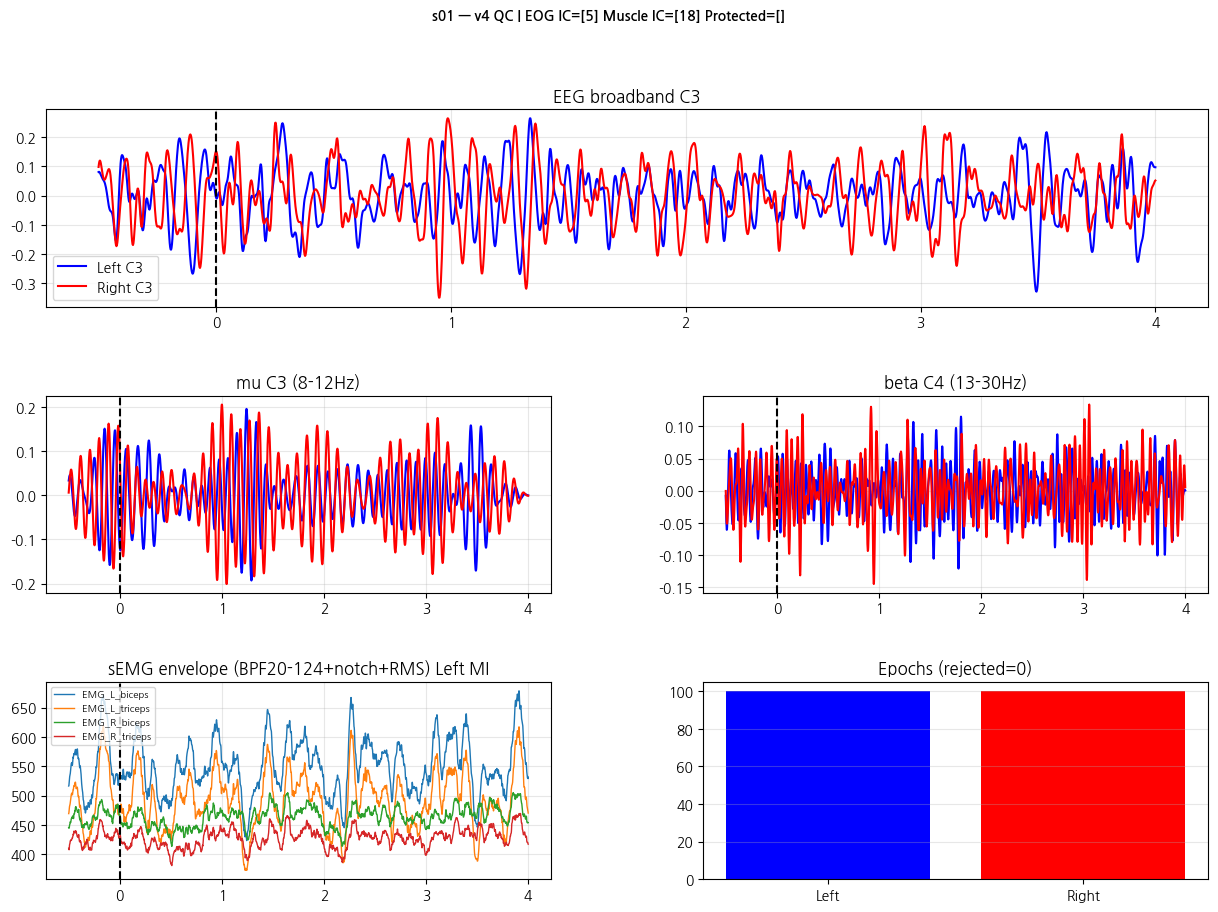

📊 저장: /content/drive/MyDrive/BCI_Research/preprocessed/member_A/QC_sub01_v4.png


In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

test_sid = AVAILABLE_SUBJECTS[0]
print(f'🔬 s{test_sid:02d} 테스트 (force_redo={CONFIG["force_redo"]})')
result = preprocess_subject(test_sid, CONFIG, READ_DIR)
print(json.dumps(result, indent=2, default=str))

if result['status'] == 'OK':
    h5p = os.path.join(CONFIG['output_dir'], f'sub-{test_sid:02d}_member_A.h5')
    with h5py.File(h5p,'r') as f:
        ep_eeg = f['eeg/epochs'][:]; ep_mu = f['eeg/mu_epochs'][:]
        ep_beta = f['eeg/beta_epochs'][:]; lbls = f['labels'][:]
        ep_emg = f['emg/epochs'][:] if 'emg' in f else None
        log = json.loads(f['metadata'].attrs['ica_log'])
    print('\nICA log:', log)

    cnames = EEG_CH_NAMES[:ep_eeg.shape[1]]
    c3, c4 = cnames.index('C3'), cnames.index('C4')
    t = np.linspace(CONFIG['epoch_tmin'], CONFIG['epoch_tmax'], ep_eeg.shape[-1])
    L = np.where(lbls==1)[0]; R = np.where(lbls==2)[0]

    fig = plt.figure(figsize=(15,10))
    fig.suptitle(f's{test_sid:02d} — v4 QC | EOG IC={log.get("eog")} Muscle IC={log.get("muscle")} Protected={log.get("protected_motor")}',
                 fontsize=10, fontweight='bold')
    gs = gridspec.GridSpec(3,2, figure=fig, hspace=0.45, wspace=0.3)

    ax = fig.add_subplot(gs[0,:])
    if len(L): ax.plot(t, ep_eeg[L,c3].mean(0), 'b', label='Left C3')
    if len(R): ax.plot(t, ep_eeg[R,c3].mean(0), 'r', label='Right C3')
    ax.axvline(0,color='k',ls='--'); ax.legend(); ax.grid(alpha=.3); ax.set_title('EEG broadband C3')

    ax = fig.add_subplot(gs[1,0])
    if len(L): ax.plot(t, ep_mu[L,c3].mean(0),'b'); 
    if len(R): ax.plot(t, ep_mu[R,c3].mean(0),'r')
    ax.axvline(0,color='k',ls='--'); ax.grid(alpha=.3); ax.set_title('mu C3 (8-12Hz)')

    ax = fig.add_subplot(gs[1,1])
    if len(L): ax.plot(t, ep_beta[L,c4].mean(0),'b')
    if len(R): ax.plot(t, ep_beta[R,c4].mean(0),'r')
    ax.axvline(0,color='k',ls='--'); ax.grid(alpha=.3); ax.set_title('beta C4 (13-30Hz)')

    ax = fig.add_subplot(gs[2,0])
    if ep_emg is not None:
        t_e = np.linspace(CONFIG['epoch_tmin'], CONFIG['epoch_tmax'], ep_emg.shape[-1])
        for ci,cn in enumerate(EMG_CH_NAMES[:ep_emg.shape[1]]):
            if len(L): ax.plot(t_e, ep_emg[L,ci].mean(0), label=cn, lw=1)
        ax.axvline(0,color='k',ls='--'); ax.legend(fontsize=7); ax.grid(alpha=.3)
        ax.set_title(f'sEMG envelope (BPF20-124+notch+RMS) Left MI')
    else:
        ax.text(0.5,0.5,'EMG 없음/sanity 실패',ha='center'); ax.set_axis_off()

    ax = fig.add_subplot(gs[2,1])
    ax.bar(['Left','Right'],[len(L),len(R)],color=['b','r'])
    ax.set_title(f'Epochs (rejected={result.get("rejected_epochs",0)})'); ax.grid(alpha=.3,axis='y')

    qcp = os.path.join(CONFIG['output_dir'], f'QC_sub{test_sid:02d}_v4.png')
    plt.savefig(qcp, dpi=120, bbox_inches='tight'); plt.show()
    print(f'📊 저장: {qcp}')

---
## STEP 5 — 전체 52명 병렬 처리

In [47]:
import scipy.io, numpy as np

path = SUBJECT_FILE_MAP[2]
print(f'읽기 경로: {path}')
print(f'파일 크기: {os.path.getsize(path)/1e6:.1f} MB')

mat  = scipy.io.loadmat(path, squeeze_me=True, struct_as_record=False)
eeg  = mat['eeg']
left = np.asarray(getattr(eeg, 'imagery_left'))

print(f'\ns02 EEG 형태: {left.shape}')
print(f'진폭 분포 (μV):')
print(f'  p50 = {np.percentile(np.abs(left), 50):.1f}')
print(f'  p90 = {np.percentile(np.abs(left), 90):.1f}')
print(f'  p99 = {np.percentile(np.abs(left), 99):.1f}')
print(f'  max = {np.abs(left).max():.1f}')
print(f'\nPTP (채널별 max-min):')
ptp = left.max(axis=-1) - left.min(axis=-1)
print(f'  평균 PTP = {ptp.mean():.1f} μV')
print(f'  최대 PTP = {ptp.max():.1f} μV')
print(f'  PTP > 600μV 채널 수: {(ptp > 600).sum()}/{len(ptp)}개')

읽기 경로: /content/drive/MyDrive/BCI_Research/GigaDB_100295/s02.mat
파일 크기: 205.4 MB

s02 EEG 형태: (68, 358400)
진폭 분포 (μV):
  p50 = 257922.0
  p90 = 675162.2
  p99 = 862173.0
  max = 888921.2

PTP (채널별 max-min):
  평균 PTP = 73123.5 μV
  최대 PTP = 333271.5 μV
  PTP > 600μV 채널 수: 68/68개


In [49]:
from joblib import Parallel, delayed
import pandas as pd
import psutil

# ── RAM 기반 n_jobs 자동 결정 ──────────────────────────────
_ram_gb = psutil.virtual_memory().total / 1e9
if _ram_gb >= 40:
    _n_jobs = CONFIG['n_jobs']
else:
    _n_jobs = 1
print(f'ℹ️  RAM {_ram_gb:.0f}GB 감지 → n_jobs={_n_jobs}')

print(f'대상 {len(AVAILABLE_SUBJECTS)}명 | n_jobs={_n_jobs} | force_redo={CONFIG["force_redo"]}')

subject_ids = AVAILABLE_SUBJECTS

if _n_jobs == 1:
    results = []
    for sid in tqdm(subject_ids, desc='전처리'):
        r = preprocess_subject(sid, CONFIG, READ_DIR)
        results.append(r)
        status = r.get('status', '?')
        if status == 'OK':
            print(f'  ✅ s{sid:02d}: {r["n_epochs"]}ep '
                  f'(L{r["left"]} R{r["right"]}) ICA제거={r["ica_excl"]}')
        elif status == 'SKIP':
            print(f'  ⏭️  s{sid:02d}: 이미 처리됨 (SKIP)')
        else:
            print(f'  ❌ s{sid:02d}: {status}')
else:
    results = Parallel(n_jobs=_n_jobs, prefer='threads', verbose=10)(
        delayed(preprocess_subject)(sid, CONFIG, READ_DIR)
        for sid in subject_ids
    )

print('🏁 완료')

ℹ️  RAM 14GB 감지 → n_jobs=1
대상 52명 | n_jobs=1 | force_redo=True


전처리:   0%|          | 0/52 [00:00<?, ?it/s]

  ✅ s01: 200ep (L100 R100) ICA제거=2
  ✅ s02: 200ep (L100 R100) ICA제거=4
  ✅ s03: 200ep (L100 R100) ICA제거=2
  ✅ s04: 200ep (L100 R100) ICA제거=0
  ✅ s05: 200ep (L100 R100) ICA제거=0
  ✅ s06: 200ep (L100 R100) ICA제거=4
  ✅ s07: 240ep (L120 R120) ICA제거=3
  ✅ s08: 200ep (L100 R100) ICA제거=3
  ✅ s09: 240ep (L120 R120) ICA제거=2
  ✅ s10: 200ep (L100 R100) ICA제거=3
  ✅ s11: 200ep (L100 R100) ICA제거=3
  ✅ s12: 200ep (L100 R100) ICA제거=5
  ✅ s13: 200ep (L100 R100) ICA제거=3
  ✅ s14: 200ep (L100 R100) ICA제거=4
  ✅ s15: 200ep (L100 R100) ICA제거=2
  ✅ s16: 200ep (L100 R100) ICA제거=1
  ✅ s17: 200ep (L100 R100) ICA제거=2
  ✅ s18: 200ep (L100 R100) ICA제거=1
  ✅ s19: 200ep (L100 R100) ICA제거=6
  ✅ s20: 200ep (L100 R100) ICA제거=2
  ✅ s21: 200ep (L100 R100) ICA제거=2
  ✅ s22: 200ep (L100 R100) ICA제거=0
  ✅ s23: 200ep (L100 R100) ICA제거=3
  ✅ s24: 200ep (L100 R100) ICA제거=2
  ✅ s25: 200ep (L100 R100) ICA제거=1
  ✅ s26: 200ep (L100 R100) ICA제거=3
  ✅ s27: 200ep (L100 R100) ICA제거=6
  ✅ s28: 200ep (L100 R100) ICA제거=1
  ✅ s29: 200ep (L100

---
## STEP 6 — 요약 & results.csv

In [50]:
import pandas as pd
df = pd.DataFrame(results)
ok = df[df['status']=='OK']; fail = df[~df['status'].isin(['OK','SKIP'])]
print(f"OK: {len(ok)} | SKIP: {(df['status']=='SKIP').sum()} | FAIL: {len(fail)}")
if len(ok):
    print(f"  평균 epoch     : {ok['n_epochs'].mean():.1f}")
    print(f"  평균 ICA 제거  : {ok['ica_excl'].mean():.1f} (EOG {ok['ica_eog'].mean():.1f} + Muscle {ok['ica_muscle'].mean():.1f}, 보호 {ok['ica_protected'].mean():.1f})")
    print(f"  평균 reject    : {ok['rejected_epochs'].mean():.1f}")
    if 'emg_mean_snr' in ok: print(f"  평균 EMG SNR   : {ok['emg_mean_snr'].mean():.2f}")
if len(fail):
    print('\n실패:')
    for _,r in fail.iterrows(): print(f"  s{r['sid']:02d}: {r['status']}")

df.to_csv(os.path.join(CONFIG['output_dir'],'summary_member_A_v4.csv'), index=False)
print('✅ summary_member_A_v4.csv 저장')

OK: 52 | SKIP: 0 | FAIL: 0
  평균 epoch     : 202.3
  평균 ICA 제거  : 2.3 (EOG 1.2 + Muscle 1.2, 보호 0.0)
  평균 reject    : 0.0
✅ summary_member_A_v4.csv 저장


In [51]:
# 나눔 폰트 설치 및 matplotlib 캐시 삭제
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [52]:
import os, h5py, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

print("============================================================")
print("  STEP 7 — 전체 피험자(52명) QC 이미지 일괄 생성 및 저장")
print("============================================================")

# 1. 시각화 이미지를 모아둘 전용 폴더 생성 (깔끔한 관리를 위해)
qc_dir = os.path.join(CONFIG['output_dir'], 'QC_Plots')
os.makedirs(qc_dir, exist_ok=True)

# 2. STEP 6에서 만든 summary csv를 읽어와서 성공한 피험자와 reject 개수 확인
summary_csv_path = os.path.join(CONFIG['output_dir'], 'summary_member_A_v4.csv')
summary_df = pd.read_csv(summary_csv_path)
ok_subjects = summary_df[summary_df['status'] == 'OK']['sid'].tolist()

# 3. 전체 피험자 순회하며 그림 그리고 저장
for sid in tqdm(ok_subjects, desc="QC Plots 생성 중"):
    
    # 해당 피험자의 reject 개수 가져오기
    rej_count = int(summary_df[summary_df['sid'] == sid]['rejected_epochs'].values[0])
    
    # H5 파일 경로
    h5p = os.path.join(CONFIG['output_dir'], f'sub-{sid:02d}_member_A.h5')
    if not os.path.exists(h5p):
        continue

    # 데이터 로드
    with h5py.File(h5p, 'r') as f:
        ep_eeg = f['eeg/epochs'][:]
        ep_mu = f['eeg/mu_epochs'][:]
        ep_beta = f['eeg/beta_epochs'][:]
        lbls = f['labels'][:]
        ep_emg = f['emg/epochs'][:] if 'emg' in f else None
        log = json.loads(f['metadata'].attrs['ica_log'])

    # 시각화 설정
    cnames = EEG_CH_NAMES[:ep_eeg.shape[1]]
    
    # 혹시 C3, C4가 없는 경우 에러 방지
    if 'C3' not in cnames or 'C4' not in cnames:
        continue
        
    c3, c4 = cnames.index('C3'), cnames.index('C4')
    t = np.linspace(CONFIG['epoch_tmin'], CONFIG['epoch_tmax'], ep_eeg.shape[-1])
    L = np.where(lbls==1)[0]; R = np.where(lbls==2)[0]

    # 그림판 생성 (화면엔 안 띄우고 백그라운드에서 그림)
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle(f'Subject {sid:02d} — v4 QC | EOG IC={log.get("eog")} Muscle IC={log.get("muscle")} Protected={log.get("protected_motor")}',
                 fontsize=12, fontweight='bold')
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # (1) EEG Broadband
    ax = fig.add_subplot(gs[0,:])
    if len(L): ax.plot(t, ep_eeg[L,c3].mean(0), 'b', label='Left C3')
    if len(R): ax.plot(t, ep_eeg[R,c3].mean(0), 'r', label='Right C3')
    ax.axvline(0, color='k', ls='--'); ax.legend(); ax.grid(alpha=.3); ax.set_title('EEG broadband C3')

    # (2) Mu Band (8-12Hz)
    ax = fig.add_subplot(gs[1,0])
    if len(L): ax.plot(t, ep_mu[L,c3].mean(0),'b') 
    if len(R): ax.plot(t, ep_mu[R,c3].mean(0),'r')
    ax.axvline(0, color='k', ls='--'); ax.grid(alpha=.3); ax.set_title('mu C3 (8-12Hz)')

    # (3) Beta Band (13-30Hz)
    ax = fig.add_subplot(gs[1,1])
    if len(L): ax.plot(t, ep_beta[L,c4].mean(0),'b')
    if len(R): ax.plot(t, ep_beta[R,c4].mean(0),'r')
    ax.axvline(0, color='k', ls='--'); ax.grid(alpha=.3); ax.set_title('beta C4 (13-30Hz)')

    # (4) sEMG Envelope
    ax = fig.add_subplot(gs[2,0])
    if ep_emg is not None:
        t_e = np.linspace(CONFIG['epoch_tmin'], CONFIG['epoch_tmax'], ep_emg.shape[-1])
        for ci, cn in enumerate(EMG_CH_NAMES[:ep_emg.shape[1]]):
            if len(L): ax.plot(t_e, ep_emg[L,ci].mean(0), label=cn, lw=1)
        ax.axvline(0, color='k', ls='--'); ax.legend(fontsize=7); ax.grid(alpha=.3)
        ax.set_title('sEMG envelope (BPF20-124+notch+RMS) Left MI')
    else:
        ax.text(0.5, 0.5, 'No EMG Data', ha='center'); ax.set_axis_off()

    # (5) Epoch Rejection Bar Chart
    ax = fig.add_subplot(gs[2,1])
    ax.bar(['Left', 'Right'], [len(L), len(R)], color=['b', 'r'])
    ax.set_title(f'Retained Epochs (Rejected={rej_count})'); ax.grid(alpha=.3, axis='y')

    # 4. 이미지 저장 및 메모리 해제 (매우 중요!)
    qcp_path = os.path.join(qc_dir, f'QC_sub{sid:02d}_v4.png')
    plt.savefig(qcp_path, dpi=120, bbox_inches='tight')
    plt.close(fig) # 메모리 누수 방지

print(f"✅ 총 {len(ok_subjects)}명의 QC 이미지 생성이 완료되었습니다.")
print(f"📂 저장 위치: {qc_dir}")

  STEP 7 — 전체 피험자(52명) QC 이미지 일괄 생성 및 저장


QC Plots 생성 중:   0%|          | 0/52 [00:00<?, ?it/s]

✅ 총 52명의 QC 이미지 생성이 완료되었습니다.
📂 저장 위치: /content/drive/MyDrive/BCI_Research/preprocessed/member_A/QC_Plots
